In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os, shutil, hashlib
from pathlib import Path

HAM_PATH = Path("/content/drive/MyDrive/capstone/HAM10000")
EXTRA_PATH = Path("/content/drive/MyDrive/capstone/ISIC_EXTRA")

def sha1(p, chunk=1024*1024):
    h = hashlib.sha1()
    with open(p, "rb") as f:
        while True:
            b = f.read(chunk)
            if not b: break
            h.update(b)
    return h.hexdigest()

def merge_class(class_name):
    src_dir = EXTRA_PATH / class_name
    dst_dir = HAM_PATH / class_name
    dst_dir.mkdir(parents=True, exist_ok=True)

    # Build hash set of existing files to avoid true duplicates
    existing_hashes = set()
    for f in dst_dir.glob("*"):
        if f.is_file():
            try:
                existing_hashes.add(sha1(f))
            except:
                pass

    copied = 0
    skipped = 0
    for f in src_dir.glob("*"):
        if not f.is_file():
            continue
        try:
            h = sha1(f)
        except:
            skipped += 1
            continue

        if h in existing_hashes:
            skipped += 1
            continue

        # keep same filename; if conflict, add suffix
        target = dst_dir / f.name
        if target.exists():
            stem = target.stem
            suf = target.suffix
            k = 1
            while True:
                target = dst_dir / f"{stem}_extra{k}{suf}"
                if not target.exists():
                    break
                k += 1

        shutil.copy2(f, target)
        existing_hashes.add(h)
        copied += 1

    print(f"{class_name}: copied {copied}, skipped {skipped}")

merge_class("akiec")
merge_class("mel")
print("Done merging ISIC_EXTRA into HAM10000.")


akiec: copied 0, skipped 600
mel: copied 0, skipped 1500
Done merging ISIC_EXTRA into HAM10000.


In [ ]:
import tensorflow as tf
import numpy as np
from pathlib import Path

DATASET_PATH = "/content/drive/MyDrive/capstone/HAM10000"
MODEL_PATH   = "/content/drive/MyDrive/resnet50_skin_disease_finetuned.keras"  # <-- change if needed
OUT_PATH     = "/content/drive/MyDrive/resnet50_skin_disease_finetuned_v2.keras"

img_size = (224, 224)
batch_size = 32
seed = 42

train_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.20,
    subset="training",
    seed=seed,
    image_size=img_size,
    batch_size=batch_size
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.20,
    subset="validation",
    seed=seed,
    image_size=img_size,
    batch_size=batch_size
)

class_names = train_ds.class_names
num_classes = len(class_names)
print("Classes:", class_names)

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(2000).prefetch(AUTOTUNE)
val_ds   = val_ds.cache().prefetch(AUTOTUNE)

# ---- class weights (from training split) ----
counts = np.zeros(num_classes, dtype=np.int64)
for _, y in train_ds:
    y_np = y.numpy()
    for c in range(num_classes):
        counts[c] += np.sum(y_np == c)

total = np.sum(counts)
class_weight = {i: (total / (num_classes * counts[i])) for i in range(num_classes)}
print("Train counts:", dict(zip(class_names, counts)))
print("Class weights:", class_weight)

# ---- focal loss ----
def sparse_focal_loss(gamma=2.0, alpha=0.25):
    def loss(y_true, y_pred):
        y_true = tf.cast(y_true, tf.int32)
        y_true_oh = tf.one_hot(y_true, depth=tf.shape(y_pred)[-1])
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1.0 - 1e-7)
        ce = -y_true_oh * tf.math.log(y_pred)
        weight = alpha * tf.pow(1 - y_pred, gamma)
        fl = weight * ce
        return tf.reduce_sum(fl, axis=-1)
    return loss

# ---- load model ----
model = tf.keras.models.load_model(MODEL_PATH, compile=False)

# ---- fine-tune gently ----
model.trainable = True

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss=sparse_focal_loss(gamma=2.0, alpha=0.25),
    metrics=["accuracy"]
)

callbacks = [
    tf.keras.callbacks.ModelCheckpoint(OUT_PATH, monitor="val_accuracy", save_best_only=True, mode="max"),
    tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, verbose=1),
    tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True),
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    class_weight=class_weight,
    callbacks=callbacks
)

print("Saved best model to:", OUT_PATH)

Found 11033 files belonging to 7 classes.
Using 8827 files for training.
Found 11033 files belonging to 7 classes.
Using 2206 files for validation.
Classes: ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']
Train counts: {'akiec': np.int64(643), 'bcc': np.int64(399), 'bkl': np.int64(895), 'df': np.int64(92), 'mel': np.int64(1346), 'nv': np.int64(5341), 'vasc': np.int64(111)}
Class weights: {0: np.float64(1.9611197511664074), 1: np.float64(3.1604010025062657), 2: np.float64(1.4089385474860334), 3: np.float64(13.706521739130435), 4: np.float64(0.936849925705795), 5: np.float64(0.23609810896835798), 6: np.float64(11.36036036036036)}
Epoch 1/20
276/276 ━━━━━━━━━━━━━━━━━━━━ 451s 2s/step - accuracy: 0.8093 - loss: 0.0860 - val_accuracy: 0.8046 - val_loss: 0.0837 - learning_rate: 1.0000e-05
Epoch 2/20
276/276 ━━━━━━━━━━━━━━━━━━━━ 76s 276ms/step - accuracy: 0.8035 - loss: 0.0564 - val_accuracy: 0.8060 - val_loss: 0.0815 - learning_rate: 1.0000e-05
Epoch 3/20
276/276 ━━━━━━━━━━━━━━━━━━━━ 77s 2

In [ ]:
import tensorflow as tf
import numpy as np

DATASET_PATH = "/content/drive/MyDrive/capstone/HAM10000"
MODEL_PATH   = "/content/drive/MyDrive/resnet50_skin_disease_finetuned_v2.keras"
OUT_PATH     = "/content/drive/MyDrive/resnet50_skin_disease_finetuned_v3.keras"

img_size = (224, 224)
batch_size = 32
seed = 42

train_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.20,
    subset="training",
    seed=seed,
    image_size=img_size,
    batch_size=batch_size
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.20,
    subset="validation",
    seed=seed,
    image_size=img_size,
    batch_size=batch_size
)

class_names = train_ds.class_names
num_classes = len(class_names)
print("Classes:", class_names)

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(2000).prefetch(AUTOTUNE)
val_ds   = val_ds.cache().prefetch(AUTOTUNE)

# ---- class weights (same method as your best script) ----
counts = np.zeros(num_classes, dtype=np.int64)
for _, y in train_ds:
    y_np = y.numpy()
    for c in range(num_classes):
        counts[c] += np.sum(y_np == c)

total = np.sum(counts)
class_weight = {i: (total / (num_classes * counts[i])) for i in range(num_classes)}
print("Train counts:", dict(zip(class_names, counts)))
print("Class weights:", class_weight)

# ---- sparse focal loss (same as your best script) ----
def sparse_focal_loss(gamma=1.5, alpha=0.25):
    # gamma lowered from 2.0 -> 1.5 to help nv not drop
    def loss(y_true, y_pred):
        y_true = tf.cast(y_true, tf.int32)
        y_true_oh = tf.one_hot(y_true, depth=tf.shape(y_pred)[-1])
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1.0 - 1e-7)
        ce = -y_true_oh * tf.math.log(y_pred)
        weight = alpha * tf.pow(1 - y_pred, gamma)
        return tf.reduce_sum(weight * ce, axis=-1)
    return loss

# ---- load model exactly like before (compile=False) ----
model = tf.keras.models.load_model(MODEL_PATH, compile=False)

# ---- fine-tune gently (prevent regression) ----
model.trainable = True
for layer in model.layers[:-40]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=3e-6),  # smaller than before
    loss=sparse_focal_loss(gamma=1.5, alpha=0.25),
    metrics=["accuracy"]
)

callbacks = [
    tf.keras.callbacks.ModelCheckpoint(OUT_PATH, monitor="val_accuracy", save_best_only=True, mode="max"),
    tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, verbose=1, min_lr=1e-7),
    tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True),
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    class_weight=class_weight,
    callbacks=callbacks
)

print("Saved best model to:", OUT_PATH)

Found 11033 files belonging to 7 classes.
Using 8827 files for training.
Found 11033 files belonging to 7 classes.
Using 2206 files for validation.
Classes: ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']
Train counts: {'akiec': np.int64(643), 'bcc': np.int64(399), 'bkl': np.int64(895), 'df': np.int64(92), 'mel': np.int64(1346), 'nv': np.int64(5341), 'vasc': np.int64(111)}
Class weights: {0: np.float64(1.9611197511664074), 1: np.float64(3.1604010025062657), 2: np.float64(1.4089385474860334), 3: np.float64(13.706521739130435), 4: np.float64(0.936849925705795), 5: np.float64(0.23609810896835798), 6: np.float64(11.36036036036036)}
Epoch 1/15
276/276 ━━━━━━━━━━━━━━━━━━━━ 258s 856ms/step - accuracy: 0.8865 - loss: 0.0208 - val_accuracy: 0.8314 - val_loss: 0.0786 - learning_rate: 3.0000e-06
Epoch 2/15
276/276 ━━━━━━━━━━━━━━━━━━━━ 67s 242ms/step - accuracy: 0.8861 - loss: 0.0186 - val_accuracy: 0.8327 - val_loss: 0.0818 - learning_rate: 3.0000e-06
Epoch 3/15
276/276 ━━━━━━━━━━━━━━━━━━━━ 0s

In [ ]:
import tensorflow as tf
import numpy as np

DATASET_PATH = "/content/drive/MyDrive/capstone/HAM10000"
MODEL_PATH   = "/content/drive/MyDrive/resnet50_skin_disease_finetuned_v3.keras"
OUT_PATH     = "/content/drive/MyDrive/resnet50_skin_disease_finetuned_v4.keras"

img_size = (224, 224)
batch_size = 32
seed = 42

train_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.20,
    subset="training",
    seed=seed,
    image_size=img_size,
    batch_size=batch_size
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.20,
    subset="validation",
    seed=seed,
    image_size=img_size,
    batch_size=batch_size
)

class_names = train_ds.class_names
num_classes = len(class_names)
print("Classes:", class_names)

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(2000).prefetch(AUTOTUNE)
val_ds   = val_ds.cache().prefetch(AUTOTUNE)

# ---- class weights ----
counts = np.zeros(num_classes, dtype=np.int64)
for _, y in train_ds:
    y_np = y.numpy()
    for c in range(num_classes):
        counts[c] += np.sum(y_np == c)

total = np.sum(counts)
class_weight = {i: (total / (num_classes * counts[i])) for i in range(num_classes)}

# ---- tiny targeted boost for akiec only ----
if "akiec" in class_names:
    akiec_idx = class_names.index("akiec")
    class_weight[akiec_idx] *= 1.15  # +15% emphasis (small bump)
print("Train counts:", dict(zip(class_names, counts)))
print("Class weights (with akiec boost):", class_weight)

# ---- focal loss ----
def sparse_focal_loss(gamma=1.5, alpha=0.25):
    def loss(y_true, y_pred):
        y_true = tf.cast(y_true, tf.int32)
        y_true_oh = tf.one_hot(y_true, depth=tf.shape(y_pred)[-1])
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1.0 - 1e-7)
        ce = -y_true_oh * tf.math.log(y_pred)
        weight = alpha * tf.pow(1 - y_pred, gamma)
        return tf.reduce_sum(weight * ce, axis=-1)
    return loss

# ---- load model ----
model = tf.keras.models.load_model(MODEL_PATH, compile=False)

# ---- slightly deeper fine-tune but still safe ----
model.trainable = True
for layer in model.layers[:-60]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=2e-6),
    loss=sparse_focal_loss(gamma=1.5, alpha=0.25),
    metrics=["accuracy"]
)

callbacks = [
    tf.keras.callbacks.ModelCheckpoint(OUT_PATH, monitor="val_accuracy", save_best_only=True, mode="max"),
    tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, verbose=1, min_lr=1e-7),
    tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=4, restore_best_weights=True),
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=12,
    class_weight=class_weight,
    callbacks=callbacks
)

print("Saved best model to:", OUT_PATH)

Found 11033 files belonging to 7 classes.
Using 8827 files for training.
Found 11033 files belonging to 7 classes.
Using 2206 files for validation.
Classes: ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']
Train counts: {'akiec': np.int64(643), 'bcc': np.int64(399), 'bkl': np.int64(895), 'df': np.int64(92), 'mel': np.int64(1346), 'nv': np.int64(5341), 'vasc': np.int64(111)}
Class weights (with akiec boost): {0: np.float64(2.2552877138413683), 1: np.float64(3.1604010025062657), 2: np.float64(1.4089385474860334), 3: np.float64(13.706521739130435), 4: np.float64(0.936849925705795), 5: np.float64(0.23609810896835798), 6: np.float64(11.36036036036036)}
Epoch 1/12
276/276 ━━━━━━━━━━━━━━━━━━━━ 130s 398ms/step - accuracy: 0.8980 - loss: 0.0168 - val_accuracy: 0.8350 - val_loss: 0.0795 - learning_rate: 2.0000e-06
Epoch 2/12
276/276 ━━━━━━━━━━━━━━━━━━━━ 99s 356ms/step - accuracy: 0.9091 - loss: 0.0145 - val_accuracy: 0.8359 - val_loss: 0.0802 - learning_rate: 2.0000e-06
Epoch 3/12
276/276 ━━━━

In [ ]:
import tensorflow as tf
import numpy as np

DATASET_PATH = "/content/drive/MyDrive/capstone/HAM10000"
MODEL_PATH   = "/content/drive/MyDrive/resnet50_skin_disease_finetuned_v4.keras"  # your latest
OUT_PATH     = "/content/drive/MyDrive/resnet50_skin_disease_finetuned_v5.keras"

img_size = (224, 224)
batch_size = 32
seed = 42

train_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH, validation_split=0.20, subset="training",
    seed=seed, image_size=img_size, batch_size=batch_size
)
val_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH, validation_split=0.20, subset="validation",
    seed=seed, image_size=img_size, batch_size=batch_size
)

class_names = train_ds.class_names
num_classes = len(class_names)
print("Classes:", class_names)

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(2000).prefetch(AUTOTUNE)
val_ds   = val_ds.cache().prefetch(AUTOTUNE)

# class weights
counts = np.zeros(num_classes, dtype=np.int64)
for _, y in train_ds:
    y_np = y.numpy()
    for c in range(num_classes):
        counts[c] += np.sum(y_np == c)

total = np.sum(counts)
class_weight = {i: (total / (num_classes * counts[i])) for i in range(num_classes)}

# small akiec boost (keep modest)
if "akiec" in class_names:
    akiec_idx = class_names.index("akiec")
    class_weight[akiec_idx] *= 1.15

print("Class weights:", class_weight)

# focal loss with LOWER gamma (helps nv)
def sparse_focal_loss(gamma=1.1, alpha=0.25):
    def loss(y_true, y_pred):
        y_true = tf.cast(y_true, tf.int32)
        y_true_oh = tf.one_hot(y_true, depth=tf.shape(y_pred)[-1])
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1.0 - 1e-7)
        ce = -y_true_oh * tf.math.log(y_pred)
        weight = alpha * tf.pow(1 - y_pred, gamma)
        return tf.reduce_sum(weight * ce, axis=-1)
    return loss

model = tf.keras.models.load_model(MODEL_PATH, compile=False)

# very gentle final tune
model.trainable = True
for layer in model.layers[:-80]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-6),
    loss=sparse_focal_loss(gamma=1.1, alpha=0.25),
    metrics=["accuracy"]
)

callbacks = [
    tf.keras.callbacks.ModelCheckpoint(OUT_PATH, monitor="val_accuracy", save_best_only=True, mode="max"),
    tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, verbose=1, min_lr=1e-7),
    tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=4, restore_best_weights=True),
]

model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=8,
    class_weight=class_weight,
    callbacks=callbacks
)

print("Saved:", OUT_PATH)

Found 11033 files belonging to 7 classes.
Using 8827 files for training.
Found 11033 files belonging to 7 classes.
Using 2206 files for validation.
Classes: ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']
Class weights: {0: np.float64(2.2552877138413683), 1: np.float64(3.1604010025062657), 2: np.float64(1.4089385474860334), 3: np.float64(13.706521739130435), 4: np.float64(0.936849925705795), 5: np.float64(0.23609810896835798), 6: np.float64(11.36036036036036)}
Epoch 1/8
276/276 ━━━━━━━━━━━━━━━━━━━━ 136s 437ms/step - accuracy: 0.9049 - loss: 0.0171 - val_accuracy: 0.8395 - val_loss: 0.0870 - learning_rate: 1.0000e-06
Epoch 2/8
276/276 ━━━━━━━━━━━━━━━━━━━━ 98s 354ms/step - accuracy: 0.9075 - loss: 0.0166 - val_accuracy: 0.8409 - val_loss: 0.0877 - learning_rate: 1.0000e-06
Epoch 3/8
276/276 ━━━━━━━━━━━━━━━━━━━━ 0s 190ms/step - accuracy: 0.9146 - loss: 0.0162
Epoch 3: ReduceLROnPlateau reducing learning rate to 4.999999987376214e-07.
276/276 ━━━━━━━━━━━━━━━━━━━━ 62s 223ms/step - accura

Model Loaded!
Found 11033 files belonging to 7 classes.
Classes: ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']

===== Per-Class Accuracy =====
akiec accuracy: 0.8537
bcc accuracy: 0.9436
bkl accuracy: 0.9800
df accuracy: 0.9478
mel accuracy: 0.8931
nv accuracy: 0.8600
vasc accuracy: 0.9930

===== Classification Report =====
              precision    recall  f1-score   support

       akiec       0.99      0.85      0.92       793
         bcc       0.91      0.94      0.93       514
         bkl       0.65      0.98      0.78      1099
          df       0.80      0.95      0.87       115
         mel       0.73      0.89      0.80      1665
          nv       0.99      0.86      0.92      6705
        vasc       0.95      0.99      0.97       142

    accuracy                           0.88     11033
   macro avg       0.86      0.92      0.88     11033
weighted avg       0.91      0.88      0.89     11033



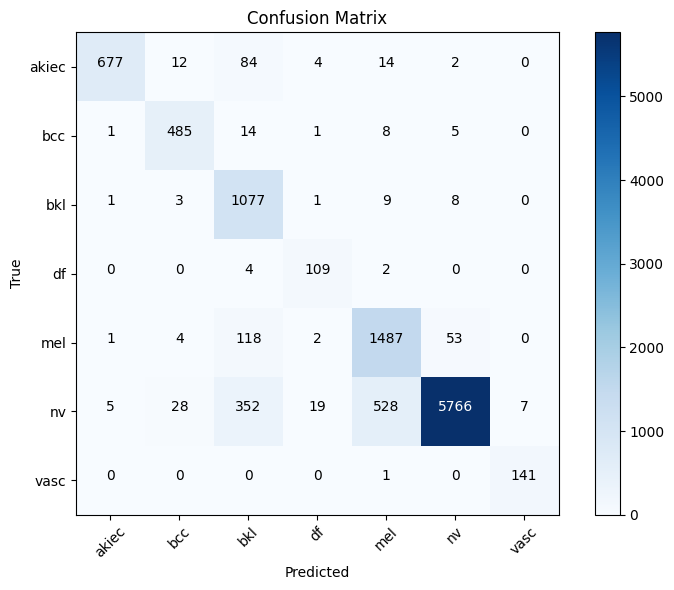

In [ ]:
# =========================================
#   EVALUATION SCRIPT FOR RESNET MODEL
#   Matches your training pipeline exactly
# =========================================

import tensorflow as tf
import numpy as np
import itertools
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt

# =========================================
#   Focal Loss Definition (MUST MATCH TRAINING)
# =========================================
def focal_loss(gamma=2., alpha=0.25):
    def loss(y_true, y_pred):
        num_classes = tf.shape(y_pred)[-1] # Dynamically get num_classes from y_pred
        y_true = tf.one_hot(tf.cast(y_true, tf.int32), depth=num_classes)
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1.0)
        cross_entropy = -y_true * tf.math.log(y_pred)
        weight = alpha * tf.pow(1 - y_pred, gamma)
        return tf.reduce_sum(weight * cross_entropy, axis=1)
    return loss

# ------------------------------------------------------
# Load your saved model
# ------------------------------------------------------
model_path = "/content/drive/MyDrive/resnet50_skin_disease_finetuned_v4.keras"
# Pass custom objects to load_model
model = tf.keras.models.load_model(model_path, custom_objects={'loss': focal_loss()})
print("Model Loaded!")

# ------------------------------------------------------
# Load validation dataset (same settings as training)
# ------------------------------------------------------

data_dir = "/content/drive/MyDrive/capstone/HAM10000"  # ← CHANGED TO CORRECT PATH
img_size = (224, 224) # Changed from (224, 224) to (380, 380) to match model input
batch_size = 32

validation_ds = tf.keras.preprocessing.image_dataset_from_directory(
    data_dir,
    image_size=img_size,
    batch_size=batch_size,
    label_mode="categorical",
    shuffle=False
)

class_names = validation_ds.class_names
num_classes = len(class_names)

print("Classes:", class_names)

# ------------------------------------------------------
# Make predictions
# ------------------------------------------------------
y_true = []
y_pred = []

for images, labels in validation_ds:
    preds = model.predict(images, verbose=0)

    y_true.extend(np.argmax(labels.numpy(), axis=1))
    y_pred.extend(np.argmax(preds, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

# ------------------------------------------------------
# Per-class accuracy
# ------------------------------------------------------
print("\n===== Per-Class Accuracy =====")
per_class_acc = {}

for i, cls in enumerate(class_names):
    idx = np.where(y_true == i)[0]
    cls_acc = np.mean(y_pred[idx] == y_true[idx])
    per_class_acc[cls] = cls_acc
    print(f"{cls} accuracy: {cls_acc:.4f}")

# ------------------------------------------------------
# Classification Report
# ------------------------------------------------------
print("\n===== Classification Report =====")
print(classification_report(y_true, y_pred, target_names=class_names))

# ------------------------------------------------------
# Confusion Matrix
# ------------------------------------------------------
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
plt.imshow(cm, cmap='Blues')
plt.title("Confusion Matrix")
plt.colorbar()

tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names, rotation=45)
plt.yticks(tick_marks, class_names)

# Write numbers in cells
thresh = cm.max() / 2
for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
    plt.text(j, i, cm[i, j],
             horizontalalignment="center",
             color="white" if cm[i, j] > thresh else "black")

plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
plt.show()
